In [1]:
from Utils.utils_spark import retrieve_credentials, get_access_token, list_contracts

# Input the path to your client credentials here
client_id, client_secret = retrieve_credentials(file_path="adhoc_scripts\\client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)
# print(access_token)
list_contracts(access_token)

>>>> Found credentials!
>>>> Client_id=d0953****, client_secret=601d8****
>>>> Successfully fetched an access token eyJhb****, valid 604799 seconds.
>>>> All the contracts you can fetch
Spark25F Pacific 160 TFDE
Spark30F Atlantic 160 TFDE
Spark25S Pacific
Spark25Fo Pacific
Spark25FFA Pacific
Spark25FFAYearly Pacific
Spark30S Atlantic
Spark30Fo Atlantic
Spark30FFA Atlantic
Spark30FFAYearly Atlantic
SparkNWE DES 1H
SparkNWE-B 1H
SparkNWE DES 2H
SparkNWE-B 2H
SparkNWE-B F
SparkNWE DES F
SparkNWE-B Fo
SparkNWE DES Fo
SparkNWE-DES-Fin Monthly
SparkNWE-Fin Monthly
SparkSWE-B F
SparkSWE DES F
SparkSWE-B Fo
SparkSWE DES Fo
SparkSWE-DES-Fin Monthly
SparkSWE-Fin Monthly


['spark25f',
 'spark30f',
 'spark25s',
 'spark25fo',
 'spark25ffa-monthly',
 'spark25ffa-yearly',
 'spark30s',
 'spark30fo',
 'spark30ffa-monthly',
 'spark30ffa-yearly',
 'sparknwe-1h',
 'sparknwe-b-1h',
 'sparknwe-2h',
 'sparknwe-b-2h',
 'sparknwe-b-f',
 'sparknwe-f',
 'sparknwe-b-fo',
 'sparknwe-fo',
 'sparknwe-des-fin-monthly',
 'sparknwe-fin-monthly',
 'sparkswe-b-f',
 'sparkswe-f',
 'sparkswe-b-fo',
 'sparkswe-fo',
 'sparkswe-des-fin-monthly',
 'sparkswe-fin-monthly']

In [9]:
from Utils.utils_spark import fetch_freight_prices

spark30_174 = fetch_freight_prices(access_token, "spark30s", 30*30, my_vessel='174-2stroke')
spark30_174

/v1.0/contracts/spark30s/price-releases/?limit=900&vessel-type=174-2stroke
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30s/price-releases/?limit=900&vessel-type=174-2stroke


,Release Date,ticker,Period Start,USDperday,USDperdayMax,USDperdayMin
0,2026-01-16,spark30s,2026-01-31,26250,28000.0,25000.0
1,2026-01-15,spark30s,2026-01-30,35000,39000.0,32000.0
2,2026-01-14,spark30s,2026-01-29,37250,39000.0,35000.0
3,2026-01-13,spark30s,2026-01-28,44500,50000.0,41250.0
4,2026-01-12,spark30s,2026-01-27,47000,50000.0,44000.0
...,...,...,...,...,...,...
895,2022-01-04,spark30s,2022-01-19,94750,NaN,NaN
896,2021-12-30,spark30s,2022-01-14,101000,NaN,NaN
897,2021-12-21,spark30s,2022-01-05,135000,NaN,NaN
898,2021-12-17,spark30s,2022-01-01,192000,NaN,NaN


,ticker,Period Start,USDperday,USDperdayMax,USDperdayMin
Release Date,,,,,
2026-01-16,spark30s,2026-01-31,26250,28000.0,25000.0
2026-01-15,spark30s,2026-01-30,35000,39000.0,32000.0
2026-01-14,spark30s,2026-01-29,37250,39000.0,35000.0
2026-01-13,spark30s,2026-01-28,44500,50000.0,41250.0
2026-01-12,spark30s,2026-01-27,47000,50000.0,44000.0
...,...,...,...,...,...
2022-01-04,spark30s,2022-01-19,94750,NaN,NaN
2021-12-30,spark30s,2022-01-14,101000,NaN,NaN
2021-12-21,spark30s,2022-01-05,135000,NaN,NaN


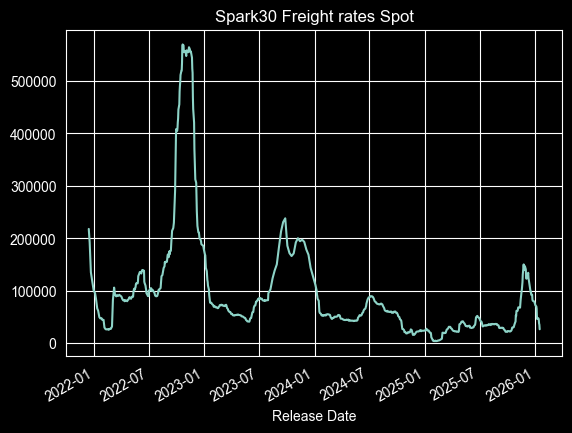

In [10]:
df = spark30_174.copy()
df.set_index("Release Date", inplace=True)
df["USDperday"].plot(title="Spark30 Freight rates Spot")
df

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df["USDperday"], label="Spark30 Freight rates Spot", bins=100);

In [11]:
from Utils.utils_spark import fetch_ffa_prices

my_dict = fetch_ffa_prices(access_token, "spark30ffa-monthly", 2, latest_only=True)

spark30ffa-monthly
Fetching https://api.sparkcommodities.com/v1.0/contracts/spark30ffa-monthly/price-releases/latest/
>>>> Get latest price release for spark30ffa-monthly
release date = 2026-01-15
- release date = 2026-01-15


In [18]:
from Utils.utils_spark import fetch_ffa_prices_for_month_only
import numpy as np
month_tenor = "Apr-2027"
dict_freight_std_by_month = {}
year = 2026
for month_tenor in [m+str(year) for m in ["Feb-", "Mar-","Apr-","May-","Jun-","Jul-","Aug-","Sep-","Oct-","Nov-","Dec-"]]:
    df_month = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 30*30, month_tenor)
    logreturns = np.log(df_month.Spark / df_month.Spark.shift(-1)).dropna()
    std_month = logreturns.std()*np.sqrt(252)
    dict_freight_std_by_month[month_tenor] = std_month

print(dict_freight_std_by_month)

spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
{'Feb-2026': np.float64(0.5257224579748875), 'Mar-2026': np.float64(0.4272821154327676), 'Apr-2026': np.float64(0.35470422036485266), 'May-2026': np.float64(0.38161671240767076), 'Jun-2026': np.float64(0.3400697543366433), 'Jul-2026': np.float64(0.3253155723185065), 'Aug-2026': np.float64(0.30515660917664256), 'Sep-2026': np.float64(0.27712134963192675), 'Oct-2026': np.float64(0.33314885877716155), 'Nov-2026': np.float64(0.3194520647776239), 'Dec-2026': np.float64(0.3005430119110691)}


In [20]:
np.mean([v for v in dict_freight_std_by_month.values()])

np.float64(0.3536484297372502)

In [15]:
dict_freight_std_by_month

{'Jan-2027': np.float64(0.1436788673510875),
 'Feb-2027': np.float64(0.1596549882787137),
 'Mar-2027': np.float64(0.160393412239646),
 'Apr-2027': np.float64(0.11358911725773227),
 'May-2027': np.float64(0.0874439161666468),
 'Jun-2027': np.float64(0.07965593366104731),
 'Jul-2027': np.float64(0.07017909166209002),
 'Aug-2027': np.float64(0.0711954804313588),
 'Sep-2027': np.float64(0.06356911069866941),
 'Oct-2027': np.float64(0.07193090377417106),
 'Nov-2027': np.float64(0.11435402563484927),
 'Dec-2027': np.float64(0.1270129944468328)}

In [4]:
current_ffa_prices = {}

for month_tenor in [m+str(year) for m in ["Feb-", "Mar-","Apr-","May-","Jun-","Jul-","Aug-","Sep-","Oct-","Nov-","Dec-"]]:
    df_month = fetch_ffa_prices_for_month_only(access_token, "spark30ffa-monthly", 1, month_tenor);
    current_ffa_prices[month_tenor] = df_month.Spark.values[0].tolist()

days = {'Feb-2026': 28,
 'Mar-2026': 31,
 'Apr-2026': 30,
 'May-2026': 31,
 'Jun-2026': 30,
 'Jul-2026': 31,
 'Aug-2026': 31,
 'Sep-2026': 30,
 'Oct-2026': 31,
 'Nov-2026': 30,
 'Dec-2026': 31}


spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly
spark30ffa-monthly


In [25]:
from datetime import date
from Pricers.european_option import black76_price

pricing_date = date(2026, 1, 16)
expiry_date = date(2026, 10, 31)
fwd_price = 51063
strike = 58000
option_type = "c"
vol = 0.15
r = 0.02
opt27_value = black76_price(
    pricing_date,
    expiry_date,
    fwd_price,
    strike,
    option_type,
    vol,
    r
) * 365

opt28_value = black76_price(
    pricing_date,
    expiry_date,
    60500,
    strike,
    option_type,
    vol,
    r
) * 30 * 8

year=2026

bleed_2026 = 0
for m in days:
    bleed_2026 += days[m] * (current_ffa_prices[m] - 40000)

print(f"2027 Freight option value in USD: {opt27_value:.2f}")
print(f"2028 Freight option value in USD: {opt28_value:.2f}")
print(f"2026 Bleeding = {bleed_2026:.2f}")

2027 Freight option value in USD: 235523.87
2028 Freight option value in USD: 1075714.65
2026 Bleeding = -1321750.00


In [54]:
current_ffa_prices

{'Feb-2026': 24000,
 'Mar-2026': 22500,
 'Apr-2026': 24000,
 'May-2026': 26500,
 'Jun-2026': 30000,
 'Jul-2026': 32250,
 'Aug-2026': 36500,
 'Sep-2026': 42500,
 'Oct-2026': 49500,
 'Nov-2026': 53750,
 'Dec-2026': 54000}

In [5]:
import pandas as pd
import datetime

from Utils.utils_spark import retrieve_credentials, get_access_token, list_contracts, do_api_get_query

# Input the path to your client credentials here
client_id, client_secret = retrieve_credentials(file_path="adhoc_scripts\\client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)
# print(access_token)
list_contracts(access_token)

def fetch_deshub_releases(access_token, unit, limit=None, offset=None, terminal=None):

    query_params = "?unit={}".format(unit)
    if limit is not None:
        query_params += "&limit={}".format(limit)
    if offset is not None:
        query_params += "&offset={}".format(offset)
    if terminal is not None:
        query_params += "&terminal={}".format(terminal)


    content = do_api_get_query(
        uri="/beta/access/des-hub-netbacks/{}".format(query_params), access_token=access_token
    )

    return content

def deshub_organise_dataframe(data):
    """
    This function sorts the API content into a dataframe. The columns available are Release Date, Terminal, Month, Vessel Size, $/MMBtu and €/MWh.
    Essentially, this function parses the Access database using the Month, Terminal and Vessel size columns as reference.
    """
    # create columns
    data_dict = {
        'Release Date':[],
        'Terminal':[],
        'Month Index':[],
        'Delivery Month':[],
        'DES Hub Netback - TTF Basis':[],
        'DES Hub Netback - Outright':[],
        'Total Regas':[],
        'Basic Slot (Berth)':[],
        'Basic Slot (Unload/Stor/Regas)':[],
        'Basic Slot (B/U/S/R)':[],
        'Additional Storage':[],
        'Additional Sendout':[],
        'Gas in Kind': [],
        'Entry Capacity':[],
        'Commodity Charge':[]
    }

    # loop for each Terminal
    for l in data['data']:

        # assigning values to each column
        data_dict['Release Date'].append(l["releaseDate"])
        data_dict['Terminal'].append(data['metaData']['terminals'][l['terminalUuid']])
        data_dict['Month Index'].append(l['monthIndex'])
        data_dict['Delivery Month'].append(l['deliveryMonth'])

        data_dict['DES Hub Netback - TTF Basis'].append(float(l['netbackTtfBasis']))
        data_dict['DES Hub Netback - Outright'].append(float(l['netbackOutright']))
        data_dict['Total Regas'].append(float(l['totalRegasificationCost']))
        data_dict['Basic Slot (Berth)'].append(float(l['slotBerth']))
        data_dict['Basic Slot (Unload/Stor/Regas)'].append(float(l['slotUnloadStorageRegas']))
        data_dict['Basic Slot (B/U/S/R)'].append(float(l['slotBerthUnloadStorageRegas']))
        data_dict['Additional Storage'].append(float(l['additionalStorage']))
        data_dict['Additional Sendout'].append(float(l['additionalSendout']))
        data_dict['Gas in Kind'].append(float(l['gasInKind']))
        data_dict['Entry Capacity'].append(float(l['entryCapacity']))
        data_dict['Commodity Charge'].append(float(l['commodityCharge']))


    # convert into dataframe
    df = pd.DataFrame(data_dict)

    df['Delivery Month'] = pd.to_datetime(df['Delivery Month'])
    df['Release Date'] = pd.to_datetime(df['Release Date'])

    # defining "Variable Regas Costs only" - here, we treat slot costs as the only fixed regas cost component
    df['DES Hub Netback - TTF Basis - Var Regas Costs Only'] = df['DES Hub Netback - TTF Basis'] \
                                                                + df['Basic Slot (B/U/S/R)'] \
                                                                + df['Basic Slot (Berth)'] \
                                                                + df['Basic Slot (B/U/S/R)']

    return df

def loop_historical_data(token, n_offset):
    # initalise first set of historical data and initialising dataframe
    historical = fetch_deshub_releases(token, unit='usd-per-mmbtu', limit=30)
    hist_df = deshub_organise_dataframe(historical)
    terminal_list = list(historical['metaData']['terminals'].values())

    # Looping through earlier historical data and adding to the historical dataframe
    for i in range(1,n_offset+1):
        historical = fetch_deshub_releases(token, unit='usd-per-mmbtu', limit=30, offset=i*30)
        hist_df = pd.concat([hist_df,deshub_organise_dataframe(historical)])

    return hist_df, terminal_list

# Calling contracts endpoint to import cargo data
def fetch_cargo_releases(access_token, ticker, limit=4, offset=None):

    print(">>>> Get price releases for {}".format(ticker))

    query_params = "?limit={}".format(limit)
    if offset is not None:
        query_params += "&offset={}".format(offset)

    content = do_api_get_query(
        uri="/v1.0/contracts/{}/price-releases/{}".format(ticker, query_params),
        access_token=access_token,
    )

    my_dict = content['data']

    return my_dict

# Function to import data and then sort into a DataFrame
def cargo_to_dataframe(access_token, ticker, limit, month):

    # imports front month or forward curve prices, depending on the "month" user input
    if month == 'M+1':
        full_tick = ticker + '-b-f'
        hist_data = fetch_cargo_releases(access_token, full_tick, limit)
    else:
        full_tick = ticker + '-b-fo'
        hist_data = fetch_cargo_releases(access_token, full_tick, limit)


    release_dates = []
    period_start = []
    ticker = []
    spark = []

    spark_min = []
    spark_max = []
    cal_month = []

    # iterating through historical data points to fetch relevant data
    for release in hist_data:
            release_date = release["releaseDate"]
            ticker.append(release['contractId'])
            release_dates.append(release_date)

            mi = int(month[-1])-2

            data_point = release['data'][0]['dataPoints'][mi]

            period_start_at = data_point["deliveryPeriod"]["startAt"]
            period_start.append(period_start_at)

            spark.append(data_point['derivedPrices']['usdPerMMBtu']['spark'])
            spark_min.append(data_point['derivedPrices']['usdPerMMBtu']['sparkMin'])
            spark_max.append(data_point['derivedPrices']['usdPerMMBtu']['sparkMax'])

            cal_month.append(datetime.datetime.strptime(period_start_at, '%Y-%m-%d').strftime('%b-%Y'))


    # Converting into DataFrame
    hist_df = pd.DataFrame({
        'Release Date': release_dates,
        'ticker': ticker,
        'Period Start': period_start,
        'Price': spark,
        })


    hist_df['Price'] = pd.to_numeric(hist_df['Price'])
    hist_df['Release Date'] = pd.to_datetime(hist_df['Release Date'])

    hist_df['Release Date'] = hist_df['Release Date'].dt.tz_localize(None)

    return hist_df


>>>> Found credentials!
>>>> Client_id=d0953****, client_secret=601d8****
>>>> Successfully fetched an access token eyJhb****, valid 604799 seconds.
>>>> All the contracts you can fetch
Spark25F Pacific 160 TFDE
Spark30F Atlantic 160 TFDE
Spark25S Pacific
Spark25Fo Pacific
Spark25FFA Pacific
Spark25FFAYearly Pacific
Spark30S Atlantic
Spark30Fo Atlantic
Spark30FFA Atlantic
Spark30FFAYearly Atlantic
SparkNWE DES 1H
SparkNWE-B 1H
SparkNWE DES 2H
SparkNWE-B 2H
SparkNWE-B F
SparkNWE DES F
SparkNWE-B Fo
SparkNWE DES Fo
SparkNWE-DES-Fin Monthly
SparkNWE-Fin Monthly
SparkSWE-B F
SparkSWE DES F
SparkSWE-B Fo
SparkSWE DES Fo
SparkSWE-DES-Fin Monthly
SparkSWE-Fin Monthly


In [6]:
loops = 15
hdf, full_terms = loop_historical_data(access_token,loops)
# Choose which forward month you'd like to analyse - either front month ("M+1") or any other month up until M+11
month = 'M+1'
# Here we define which terminals we want to use in the analytics. The default is all terminals, but you can choose a subset if preferred (as demonstrated in comment below)
terms = full_terms.copy()
#terms = ['gate', 'dunkerque', 'zeebrugge']
# Import NWE/SWE LNG prices
sparknwe = cargo_to_dataframe(access_token, 'sparknwe', loops*30, month=month)
sparkswe = cargo_to_dataframe(access_token, 'sparkswe', loops*30, month=month)

# retrieve the same amount of historical data for SparkSWE as SparkNWE
sparkswe = sparkswe[sparkswe['Release Date'] >= sparknwe['Release Date'].iloc[-1]].copy()

# Combine datasets and backfill SWE data as needed (due to reduced assessment frequency)
cargo_df = pd.merge(sparknwe, sparkswe, how='left', on='Release Date')
cargo_df['Price_y'] = cargo_df['Price_y'].bfill().copy()

cargo_df = cargo_df[['Release Date', 'Price_x', 'Price_y']].copy()
cargo_df = cargo_df.rename(columns={'Price_x': 'SparkNWE',
                                    'Price_y': 'SparkSWE'})
terminal_region_dict = {
    'gate': 'nwe',
    'grain-lng': 'nwe',
    'zeebrugge': 'nwe',
    'south-hook': 'nwe',
    'dunkerque': 'nwe',
    'le-havre': 'nwe',
    'montoir': 'nwe',
    'eems-energy-terminal': 'nwe',
    'brunsbuttel': 'nwe',
    'deutsche-ostsee': 'nwe',
    'wilhelmshaven': 'nwe',
    'wilhelmshaven-2': 'nwe',
    'stade': 'nwe',
    'fos-cavaou': 'swe',
    'adriatic': 'swe',
    'olt-toscana': 'swe',
    'piombino': 'swe',
    'ravenna': 'swe',
    'tvb': 'swe'
}

>>>> Get price releases for sparknwe-b-f
>>>> Get price releases for sparkswe-b-f


In [7]:
month_df = hdf[(hdf['Terminal'] == 'gate') & (hdf['Month Index'] == month)][['Release Date', 'Delivery Month', 'DES Hub Netback - TTF Basis - Var Regas Costs Only']]
month_df = month_df.rename(columns={'DES Hub Netback - TTF Basis - Var Regas Costs Only':'gate'})

# defining a new list of terminals without "gate" in it
terms2 = [x if x != 'gate' else None for x in terms]

# iterating through list of terminals and adding data to the Terminal WTP dataframe
for t in terms2:
    if t is not None:
        tdf = hdf[(hdf['Terminal'] == t) & (hdf['Month Index'] == month)][['Release Date', 'DES Hub Netback - TTF Basis - Var Regas Costs Only']]
        month_df = month_df.merge(tdf, on='Release Date', how='left')
        month_df = month_df.rename(columns={'DES Hub Netback - TTF Basis - Var Regas Costs Only':t})

# Calculating the Average, Minimum and Maximum WTP values for all terminals (i.e. for Europe)
month_df['Ave'] = month_df[terms].mean(axis=1)
month_df['Min'] = month_df[terms].min(axis=1)
month_df['Max'] = month_df[terms].max(axis=1)

# Merging Cargo prices with the DataFrame, and backfilling data as needed so that the datasets are the same length (needed due to differing price release frequency)
month_df = month_df.merge(cargo_df, how='left', on='Release Date')
month_df['SparkNWE'] = month_df['SparkNWE'].bfill().copy()
month_df['SparkSWE'] = month_df['SparkSWE'].bfill().copy()

wtp_df = month_df[['Release Date', 'Delivery Month', 'SparkNWE', 'SparkSWE']].copy()

for t in terms:
    if terminal_region_dict[t] == 'nwe':
        wtp_df[t] = month_df[t].copy() - month_df['SparkNWE'].copy()
    elif terminal_region_dict[t] == 'swe':
        wtp_df[t] = month_df[t].copy() - month_df['SparkSWE'].copy()
    else:
        wtp_df[t] = month_df[t].copy() - month_df['SparkNWE'].copy()

# Calculating the Average, Min and Max WTP metric over all terminals
wtp_df['Ave'] = wtp_df[terms].mean(axis=1)
wtp_df['Min'] = wtp_df[terms].min(axis=1)
wtp_df['Max'] = wtp_df[terms].max(axis=1)

# Determining which is the marginal terminal for each historical date
wtp_df['Marginal Terminal'] = wtp_df[terms].abs().idxmin(axis="columns").copy()

# saving list of marginal terminals
marg_list = list(wtp_df['Marginal Terminal'].unique())
marg_list = [s for s in marg_list if isinstance(s, str)]

C:\Users\marti.fernandezreal\AppData\Local\Temp\ipykernel_40416\4007142691.py:40: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  wtp_df['Marginal Terminal'] = wtp_df[terms].abs().idxmin(axis="columns").copy()


<Axes: xlabel='Release Date'>

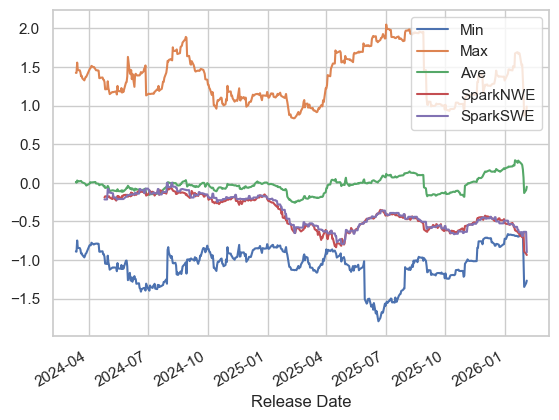

In [8]:
month_df.set_index("Release Date")[["Min", "Max", "Ave", "SparkNWE", "SparkSWE"]].plot()

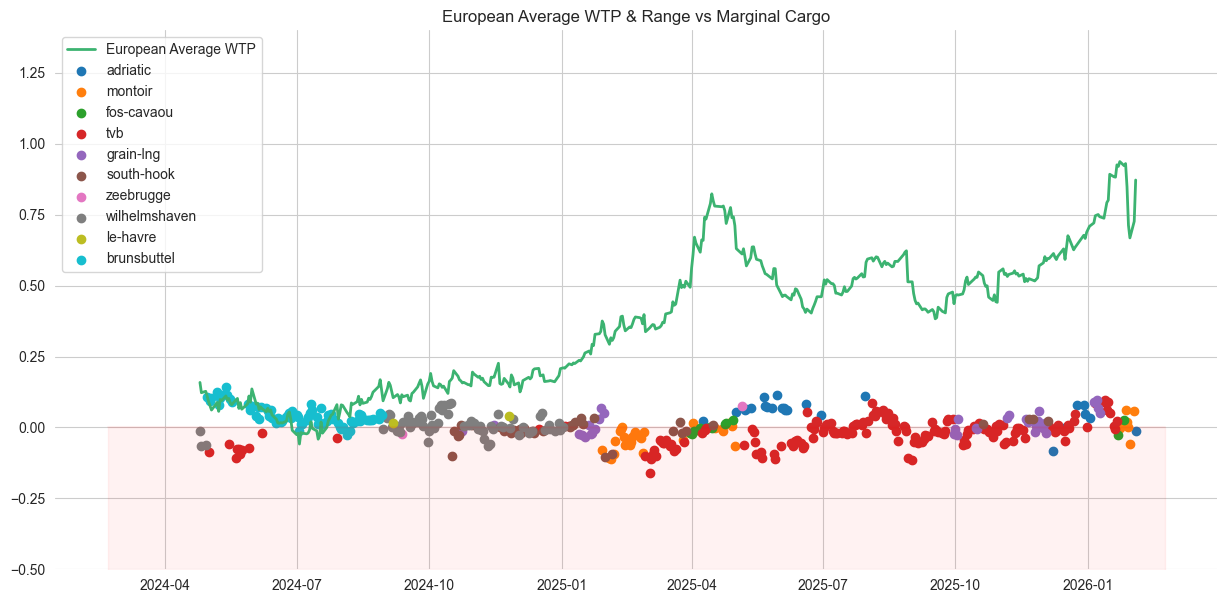

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(wtp_df['Release Date'], wtp_df['Ave'], color='mediumseagreen', linewidth=2.0, label='European Average WTP')

# Option to plot min/max range of European Average WTP
#ax.plot(wtp_df['Release Date'], wtp_df['Min'], color='steelblue', linewidth=1.0, alpha=0.06)
#ax.plot(wtp_df['Release Date'], wtp_df['Max'], color='steelblue', linewidth=1.0, alpha=0.06)
#ax.fill_between(wtp_df['Release Date'], wtp_df['Min'], wtp_df['Max'], color='steelblue', alpha=0.2)

for m in marg_list:
    tdf = wtp_df[wtp_df['Marginal Terminal'] == m][['Release Date', m]]
    ax.scatter(tdf['Release Date'], tdf[m], label=m)

# Shading <0 area of the chart
negrange = [wtp_df['Release Date'].iloc[-1] -pd.Timedelta(20, unit='day'), wtp_df['Release Date'].iloc[0] +pd.Timedelta(20, unit='day')]
ax.plot(negrange,[-1.0,-1.0], color='red', alpha=0.05)
ax.plot(negrange,[0,0], color='red', alpha=0.05)
ax.fill_between(negrange, 0, -1.0, color='red', alpha=0.05)

# Chart Aesthetics
ax.set_ylim(-0.5, 1.4)
plt.title('European Average WTP & Range vs Marginal Cargo')
plt.legend()

sns.despine(left=True, bottom=True)

In [1]:
from Utils.utils_spark import get_terminal_list, get_all_terminal_data, retrieve_credentials, get_access_token, list_contracts, do_api_get_query, list_netbacks

# Input the path to your client credentials here
client_id, client_secret = retrieve_credentials(file_path="adhoc_scripts\\client_credentials.csv")

# Authenticate:
access_token = get_access_token(client_id, client_secret)

def fetch_netback(access_token, ticker, release, via=None, laden=None, ballast=None):

    query_params = "?fob-port={}".format(ticker)
    if release is not None:
        query_params += "&release-date={}".format(release)
    if via is not None:
        query_params += "&via-point={}".format(via)
    if laden is not None:
        query_params += "&laden-congestion-days={}".format(laden)
    if ballast is not None:
        query_params += "&ballast-congestion-days={}".format(ballast)


    content = do_api_get_query(
        uri="/v1.0/netbacks/{}".format(query_params),
        access_token=access_token,
    )

    my_dict = content['data']

    return my_dict

import time
import numpy as np
import pandas as pd
tickers, fobPort_names, availablevia, reldates, dicto1 = list_netbacks(access_token)

def netbacks_history(tick, reldates, month=1, my_via=None, laden =None, ballast=None):

    delta_outrights = []
    release_date = []

    port = []

    for r in reldates:
        try:
            my_dict = fetch_netback(access_token, tickers[tick], release=r, via=my_via, laden=laden, ballast=ballast)

            dtemp = [float(m['neaMinusNwe']['outright']['usdPerMMBtu']) for m in my_dict['netbacks'][0:month]]
            # for m in my_dict['netbacks'][0:month]:
            #     dtemp.append(float(m['neaMinusNwe']['outright']['usdPerMMBtu']))
            delta_outrights.append(np.mean(dtemp))

            release_date.append(my_dict['releaseDate'])
            port.append(fobPort_names[tick])

        except:
            print('Bad Date: ' + r)

        # time.sleep(0.5)

    historical_df = pd.DataFrame({
                'Release Date': release_date,
                'FoB Port': port,
                'Delta Outrights': delta_outrights,
                })


    historical_df['Release Date'] = pd.to_datetime(historical_df['Release Date'])

    return historical_df


def select_and_sum_terminals(termlist, historical_terminals_data):

    # Unique release dates
    termrels = pd.Series(historical_terminals_data['ReleaseDate'].unique()).sort_values().to_list()[::-1]
    term_groups = historical_terminals_data.groupby('ReleaseDate')

    slots = []

    for t in termrels:
        df = term_groups.get_group(t)

        df1 = df[df['TerminalName'].isin(termlist)]
        slots.append(df1['M+0'].sum() + df1['M+1'].sum() + df1['M+2'].sum() + df1['M+3'].sum())
    return slots





>>>> Found credentials!
>>>> Client_id=d0953****, client_secret=601d8****
>>>> Successfully fetched an access token eyJhb****, valid 604799 seconds.
>>>> All the routes you can fetch


In [56]:

terminal_list = get_terminal_list(access_token)
terminal_list.head(20)

# Calling all terminal data function
all_terminal_historical = get_all_terminal_data(access_token, terminal_list)
all_terminal_historical.head()

tickers, fobPort_names, availablevia, reldates, dicto1 = list_netbacks(access_token)

via ='cogh'
my_t = 'Sabine Pass'
t = fobPort_names.index(my_t)
my_date = reldates.index('2024-01-05')

my_rels = reldates[:my_date]

df_cogh = netbacks_history(t, my_rels, month=3, my_via='cogh')

# Combining Slots and US arb data into one single DataFrame

termlist = ['Gate', 'Zeebrugge', 'Dunkerque', 'Fos Cavaou']
termlist = all_terminal_historical.TerminalName.unique()

slots = select_and_sum_terminals(termlist, all_terminal_historical)

slots_df = pd.DataFrame({
    'Release Date': df_cogh['Release Date'],
    'Arb' : df_cogh['Delta Outrights'],
    'Slots' : slots[:my_date]
})


# Displaying Slots data

slots_df.head()

>>>> All the routes you can fetch


,Release Date,Arb,Slots
0,2026-02-03,-0.321333,23
1,2026-02-02,-0.399333,24
2,2026-01-30,-0.817667,24
3,2026-01-29,-1.188000,23
4,2026-01-28,-1.215333,24


In [55]:
slots_df

,Release Date,Arb,Slots
0,2026-02-03,-0.321333,5
1,2026-02-02,-0.399333,6
2,2026-01-30,-0.817667,7
3,2026-01-29,-1.188000,4
4,2026-01-28,-1.215333,5
...,...,...,...
521,2024-01-12,-0.009000,2
522,2024-01-11,0.024667,2
523,2024-01-10,0.008333,2
524,2024-01-09,0.079000,2


In [45]:
month_df_discounts = month_df.set_index("Release Date")[["Min", "Max", "Ave", "SparkNWE", "SparkSWE"]]
slots_df_discounts = slots_df.set_index("Release Date")
common_dates = [d for d in month_df_discounts.index if d in slots_df_discounts.index]
_m = month_df_discounts.loc[common_dates]["SparkNWE"]
_arb = slots_df_discounts.loc[common_dates]["Arb"]


In [52]:
all_terminal_historical.TerminalName.unique()

array(['Ravenna', 'Isle of Grain', 'Zeebrugge', 'Dunkerque', 'Dragon',
       'Brunsbuttel', 'OLT Toscana', 'Piombino', 'Wilhelmshaven 2',
       'EemsEnergyTerminal', 'Adriatic', 'Fos Cavaou', 'Montoir',
       'Wilhelmshaven 1', 'Stade', 'South Hook', 'Inkoo',
       'Deutsche Ostsee', 'Klaipeda', 'Gate'], dtype=object)

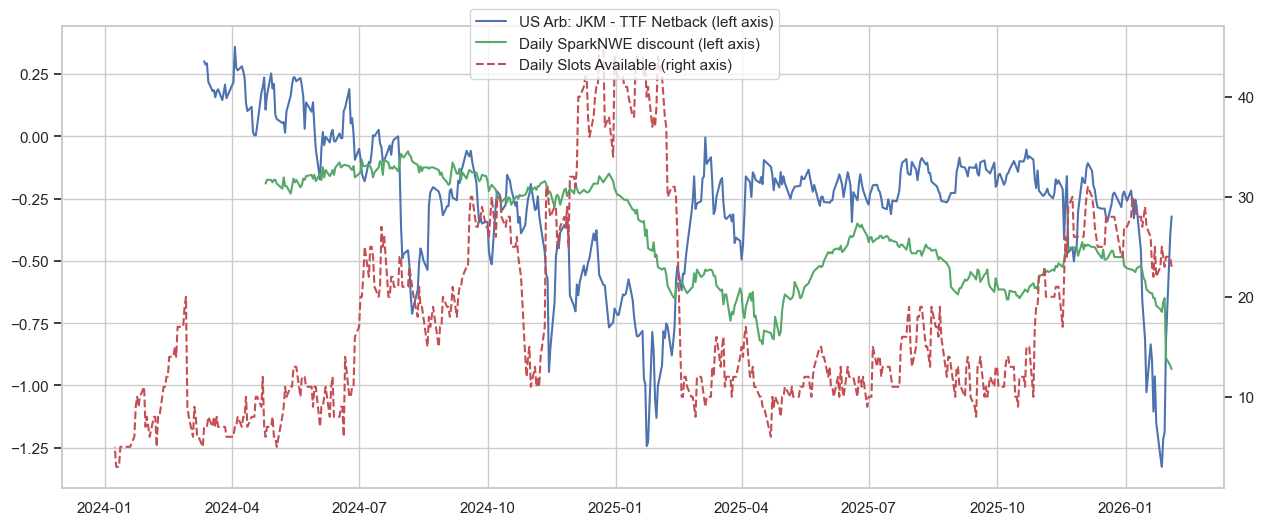

In [57]:
# Plotting

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(15,6))

ax.plot(_arb.index, _arb.values, label='US Arb: JKM - TTF Netback (left axis)')
ax.plot(_m.index, _m.values, 'g', label='Daily SparkNWE discount (left axis)')

ax2 = ax.twinx()
ax2.plot(slots_df['Release Date'], slots_df['Slots'], 'r--', label='Daily Slots Available (right axis)')

ax2.grid(False)

fig.legend(loc = 'center', bbox_to_anchor=(0.5, 0.85))

In [12]:
big_string = ""
for i in range(6, 0, -1):
    l1 = f"p{i}=(C>>{i});a{i}=(H>>{i})-(L>>{i});v{i}=(V>>{i});"
    l2 = f"d{i}=If(p{i}>p{i+1},If(d{i+1}==1,1,If(a{i}>al,1,-1)),If(d{i+1}==-1,-1,If(a{i}>al,-1,1)));"
    l3 = f"p{i}=If(p{i}>p{i+1},If(d{i+1}==1,p{i},If(a{i}>al,p{i},p{i+1})),If(d{i+1}==-1,p{i},If(a{i}>al, p{i},p{i+1})));"
    l4 = f"wv{i}=If(d{i}==d{i+1},wv{i+1}+v{i},v{i});"

    print(l1)
    print(l2)
    print(l3)
    print(l4)


p6=(C>>6);a6=(H>>6)-(L>>6);v6=(V>>6);
d6=If(p6>p7,If(d7==1,1,If(a6>al,1,-1)),If(d7==-1,-1,If(a6>al,-1,1)));
p6=If(p6>p7,If(d7==1,p6,If(a6>al,p6,p7)),If(d7==-1,p6,If(a6>al, p6,p7)));
wv6=If(d6==d7,wv7+v6,v6);
p5=(C>>5);a5=(H>>5)-(L>>5);v5=(V>>5);
d5=If(p5>p6,If(d6==1,1,If(a5>al,1,-1)),If(d6==-1,-1,If(a5>al,-1,1)));
p5=If(p5>p6,If(d6==1,p5,If(a5>al,p5,p6)),If(d6==-1,p5,If(a5>al, p5,p6)));
wv5=If(d5==d6,wv6+v5,v5);
p4=(C>>4);a4=(H>>4)-(L>>4);v4=(V>>4);
d4=If(p4>p5,If(d5==1,1,If(a4>al,1,-1)),If(d5==-1,-1,If(a4>al,-1,1)));
p4=If(p4>p5,If(d5==1,p4,If(a4>al,p4,p5)),If(d5==-1,p4,If(a4>al, p4,p5)));
wv4=If(d4==d5,wv5+v4,v4);
p3=(C>>3);a3=(H>>3)-(L>>3);v3=(V>>3);
d3=If(p3>p4,If(d4==1,1,If(a3>al,1,-1)),If(d4==-1,-1,If(a3>al,-1,1)));
p3=If(p3>p4,If(d4==1,p3,If(a3>al,p3,p4)),If(d4==-1,p3,If(a3>al, p3,p4)));
wv3=If(d3==d4,wv4+v3,v3);
p2=(C>>2);a2=(H>>2)-(L>>2);v2=(V>>2);
d2=If(p2>p3,If(d3==1,1,If(a2>al,1,-1)),If(d3==-1,-1,If(a2>al,-1,1)));
p2=If(p2>p3,If(d3==1,p2,If(a2>al,p2,p3)),If(d3==-1,p2,If(a2>

In [5]:
big_string

'price98 = (C >> 98); atr98 = (H >> 98) - (L >> 98); vol98 = (V >> 98);direction98 = If(price98 > price99, If(direction99==1, 1, If(atr98 > ATRlimit, -1, 1)), If(direction99==-1, -1, If(atr98 > ATRlimit, 1, -1)));price98 = If(price98 > price99, If(direction99==1, price98, If(atr98 > ATRlimit, price98, price99)), If(direction99==-1, price98, If(atr98 > ATRlimit, price98, price99)));wavevol98 = If(direction98==direction99, wavevol99 + vol98, vol98);price97 = (C >> 97); atr97 = (H >> 97) - (L >> 97); vol97 = (V >> 97);direction97 = If(price97 > price98, If(direction98==1, 1, If(atr97 > ATRlimit, -1, 1)), If(direction98==-1, -1, If(atr97 > ATRlimit, 1, -1)));price97 = If(price97 > price98, If(direction98==1, price97, If(atr97 > ATRlimit, price97, price98)), If(direction98==-1, price97, If(atr97 > ATRlimit, price97, price98)));wavevol97 = If(direction97==direction98, wavevol98 + vol97, vol97);price96 = (C >> 96); atr96 = (H >> 96) - (L >> 96); vol96 = (V >> 96);direction96 = If(price96 > pr